In [2]:
import numpy as np
import torch

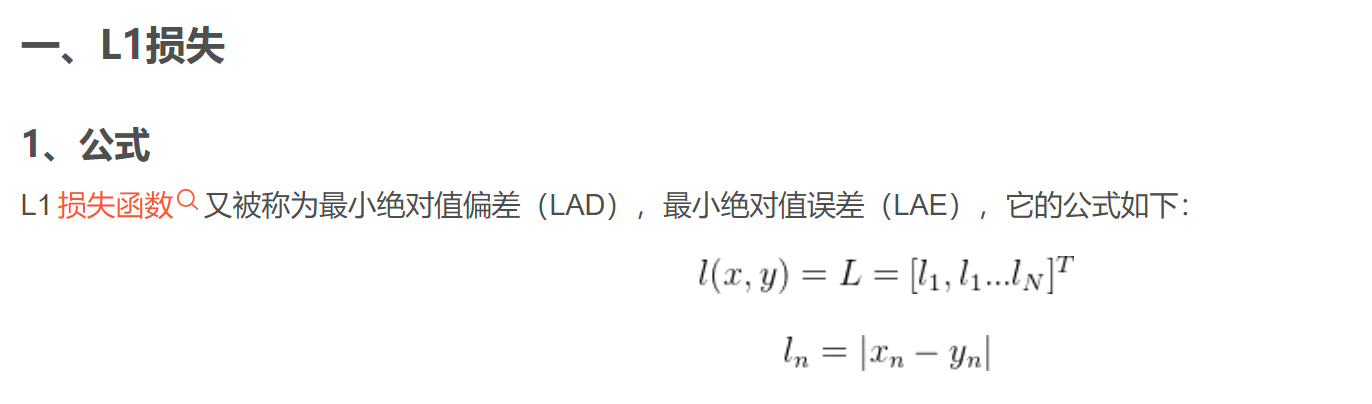

In [3]:
def l1_loss(x, y, reduction='mean'):
    dif = np.abs(x - y)
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif
 
np.random.seed(10001)
x = np.random.rand(4, 3, 100)
y = np.random.rand(4, 3, 100)
np_loss = l1_loss(x, y, 'mean')
torch_loss_fn = torch.nn.L1Loss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y))
print(np_loss, torch_loss.numpy())
# 输出：0.3279294731209465 0.3279294731209465
 

0.3279294731209465 0.3279294731209465


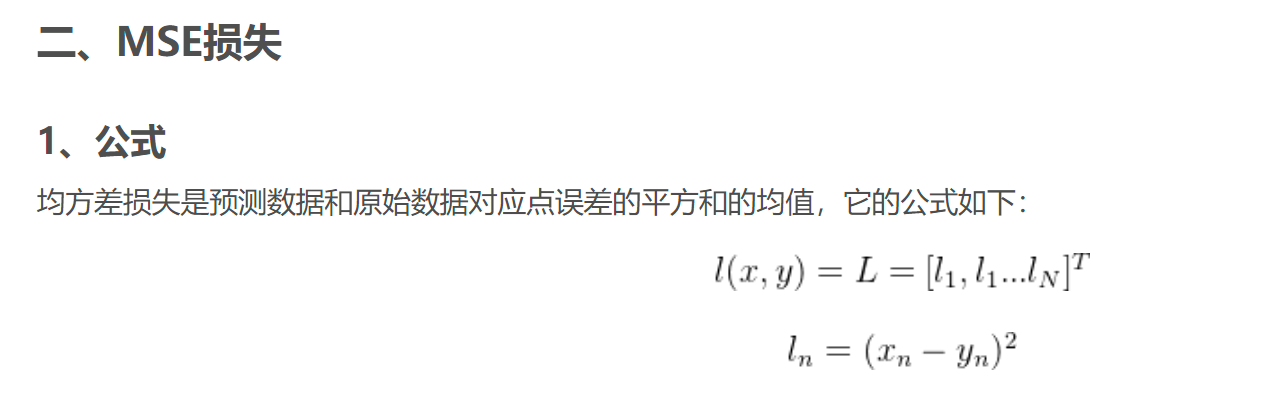

In [ ]:

def mse_loss(x, y, reduction='mean'):
    dif = np.square(x - y)
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif
 
 
np.random.seed(10001)
 
x = np.random.rand(4, 3, 100)
y = np.random.rand(4, 3, 100)
np_loss = mse_loss(x, y, 'mean')
torch_loss_fn = torch.nn.MSELoss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y))
print(np_loss, torch_loss.numpy())
# 输出：0.16281742957744108 0.16281742957744105

0.16281742957744108 0.16281742957744105


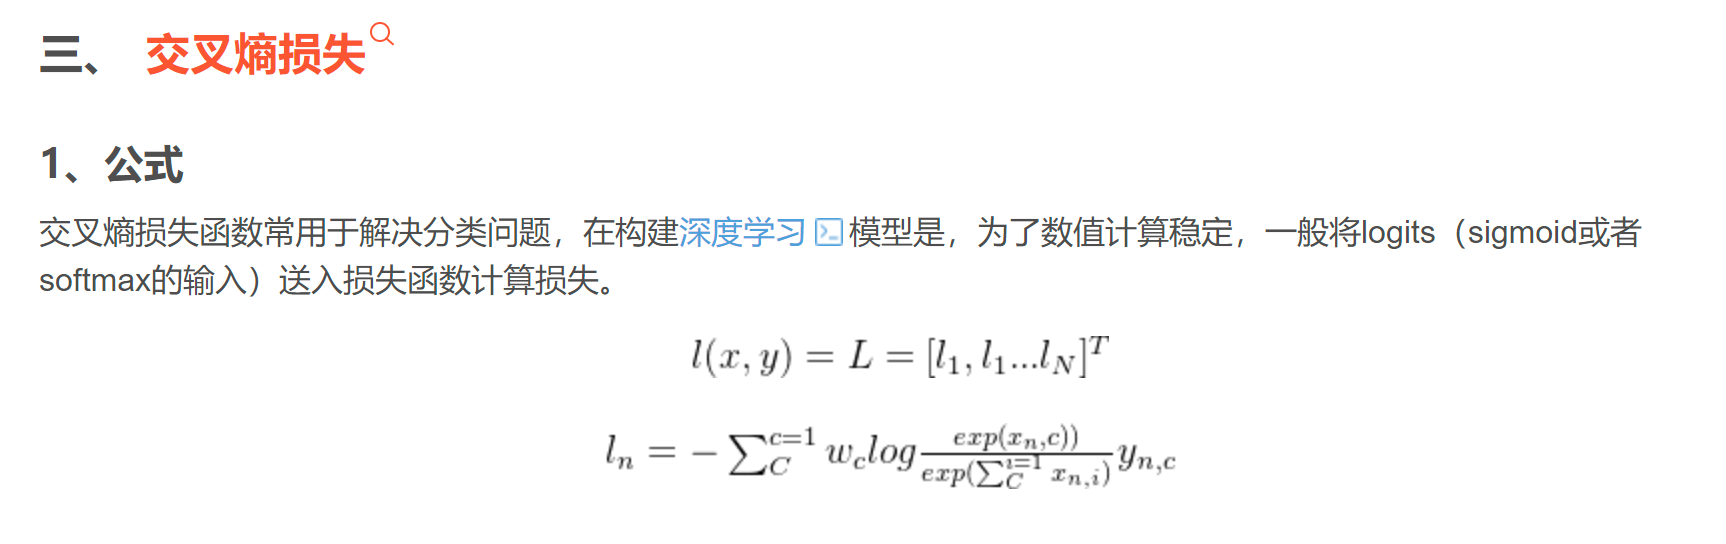

In [ ]:
def one_hot(x, num_class=None):
    if not num_class:
        num_class = np.max(x) + 1
    ohx = np.zeros((len(x), num_class))
    ohx[range(len(x)), x] = 1
    return ohx
 
 
def cross_entropy_loss(x, y, reduction='mean'):
    loss = []
    for i in range(y.shape[0]):
        loss_i = -x[i, y[i]] + np.log(np.sum(np.exp(x[i])))
        loss.append(loss_i)
    dif = np.array(loss).reshape([y.shape[0], 1])
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif


def loss_ce(y_true, y_pred, epsilon=1e-10, reduction='mean'):
    """
    计算交叉熵损失 (Cross Entropy Loss)
    
    参数:
    y_true -- 真实标签 (one-hot 编码), 形状 (N, C)
    y_pred -- 预测概率 (softmax 输出), 形状 (N, C)
    epsilon -- 防止 log(0) 的数值稳定性调整
    
    返回:
    loss -- 交叉熵损失的均值
    """
    # 防止 log(0) 发生：将 y_pred 限制在 [epsilon, 1-epsilon] 之间
    y_pred = np.clip(y_pred, epsilon, None)
    
    # 计算交叉熵损失
    ce_loss = -np.sum(y_true * np.log(y_pred), axis=1)  # 对类别求和
    if reduction == 'mean': return np.mean(ce_loss)  # loss.mean
    elif reduction == 'sum': return np.sum(ce_loss)  # loss.sum
    else: return ce_loss # loss

# x:[[0010] [0100] [1000]] y:[[2], [1], [0]]

np.random.seed(10001)
 
x = np.random.rand(4, 100).astype('float32')
y = np.random.randint(0, 100, (4,))
np_loss = cross_entropy_loss(x, y, 'mean')
print(loss_ce(one_hot(y,100),x))  # softmax(x) ->
torch_loss_fn = torch.nn.CrossEntropyLoss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y).to(torch.long))
print(np_loss, torch_loss.numpy())
# 输出：4.8294697 4.829469

1.4159597158432007
4.8294697 4.829469


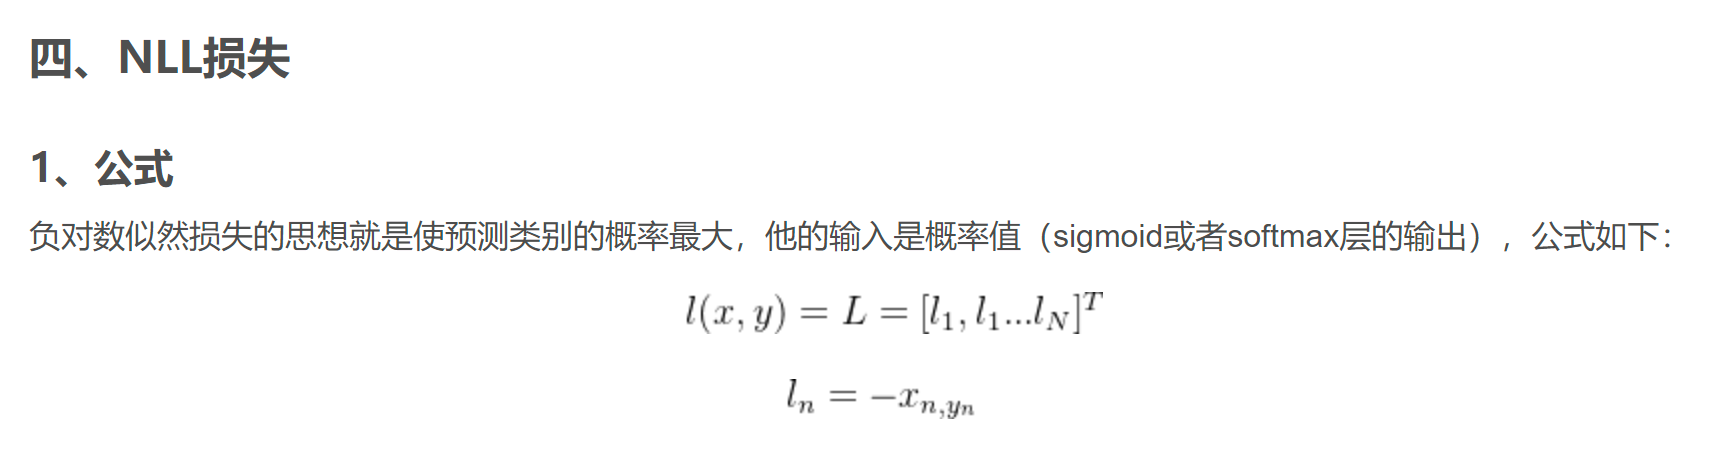

In [6]:

def log_softmax(x):
    m = np.sum(np.exp(x), axis=1, keepdims=True)
    x = np.log(x / m)
    return x
 
 
def nll_loss(x, y, reduction='mean'):
    loss = []
    for i in range(y.shape[0]):
        loss_i = -x[i, y[i]]
        loss.append(loss_i)
    dif = np.array(loss)
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif
 
 
np.random.seed(10001)
 
x = np.random.rand(4, 100).astype('float32')
x = log_softmax(x)
y = np.random.randint(0, 100, (4,))
np_loss = nll_loss(x, y, 'mean')
torch_loss_fn = torch.nn.NLLLoss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y).to(torch.long))
print(np_loss, torch_loss.numpy())
# 6.5572305 6.55723

6.5572305 6.55723


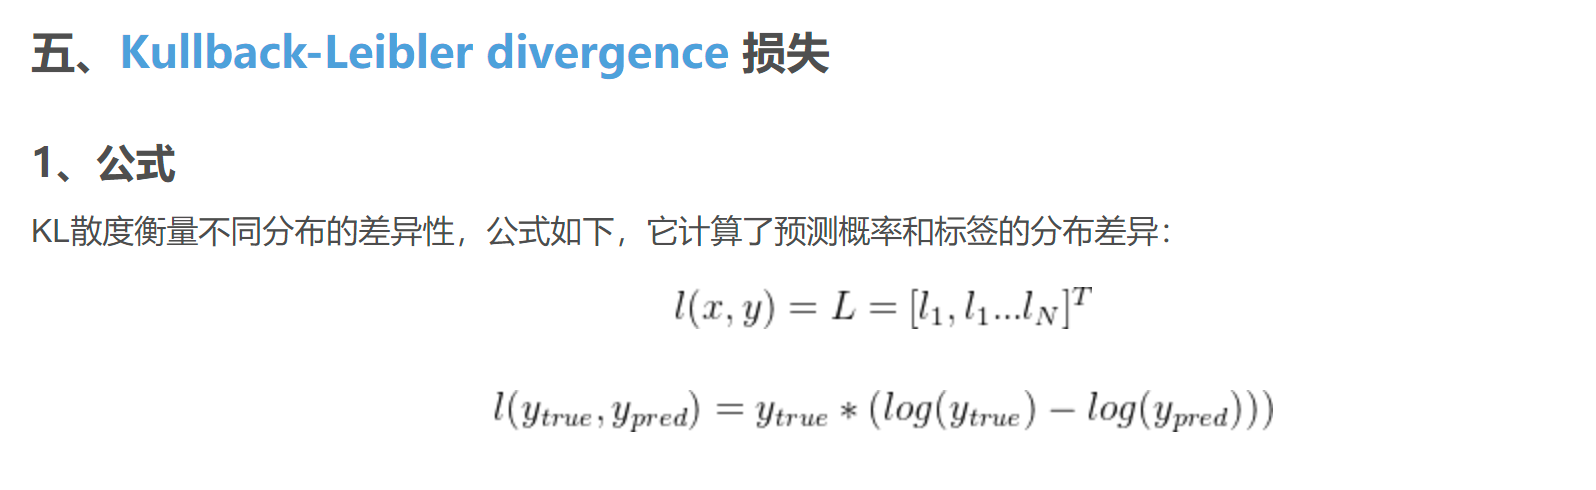

In [ ]:
def log_softmax(x):
    m = np.sum(np.exp(x), axis=1, keepdims=True)
    x = np.log(x / m)
    return x

def kldiv_loss(x, y, reduction='mean'):
    y_log = np.log(np.where(y < 1e-3, 1e-3, y))
    dif = y * (y_log - x)
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif

np.random.seed(10001)
x = np.random.rand(4, 100).astype('float32')
x = log_softmax(x)

# **确保 y 是浮点数**
y = np.random.randint(0, 2, (4, 100)).astype('float32')

np_loss = kldiv_loss(x, y, 'mean')

torch_loss_fn = torch.nn.KLDivLoss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y))  # 这里 y 现在是 float32

print(np_loss, torch_loss.numpy())

"""
在 PyTorch 中，KLDivLoss 计算的是 两个概率分布之间的 KL 散度，要求：

input（即 x）应该是 log 概率（通常由 log_softmax 计算得到）。
target（即 y）应该是概率分布，即 y 的值应该是 [0,1] 之间的浮点数，而 不能是整数。
"""

2.8793883 2.8793883


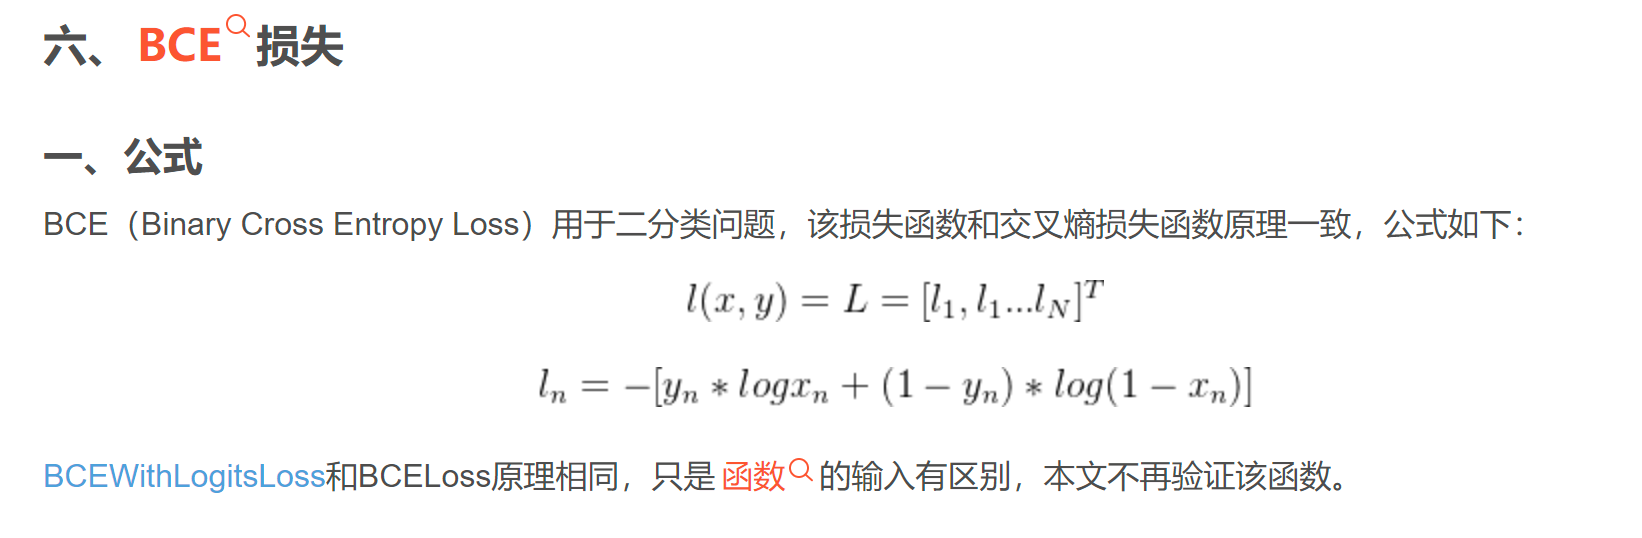

In [8]:

def binary_cross_entropy_loss(x, y, reduction='mean'):
    dif = -(y * np.log(x) + (1 - y) * np.log(1 - x))
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
 
    return dif
 
np.random.seed(10001)
x = np.random.rand(4, ).astype('float32')
y = np.random.randint(0, 1, (4, )).astype('float32')
np_loss = binary_cross_entropy_loss(x, y, 'mean')
torch_loss_fn = torch.nn.BCELoss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y))
print(np_loss, torch_loss.numpy())
# 输出：0.9325159 0.9325159

0.932516 0.9325159


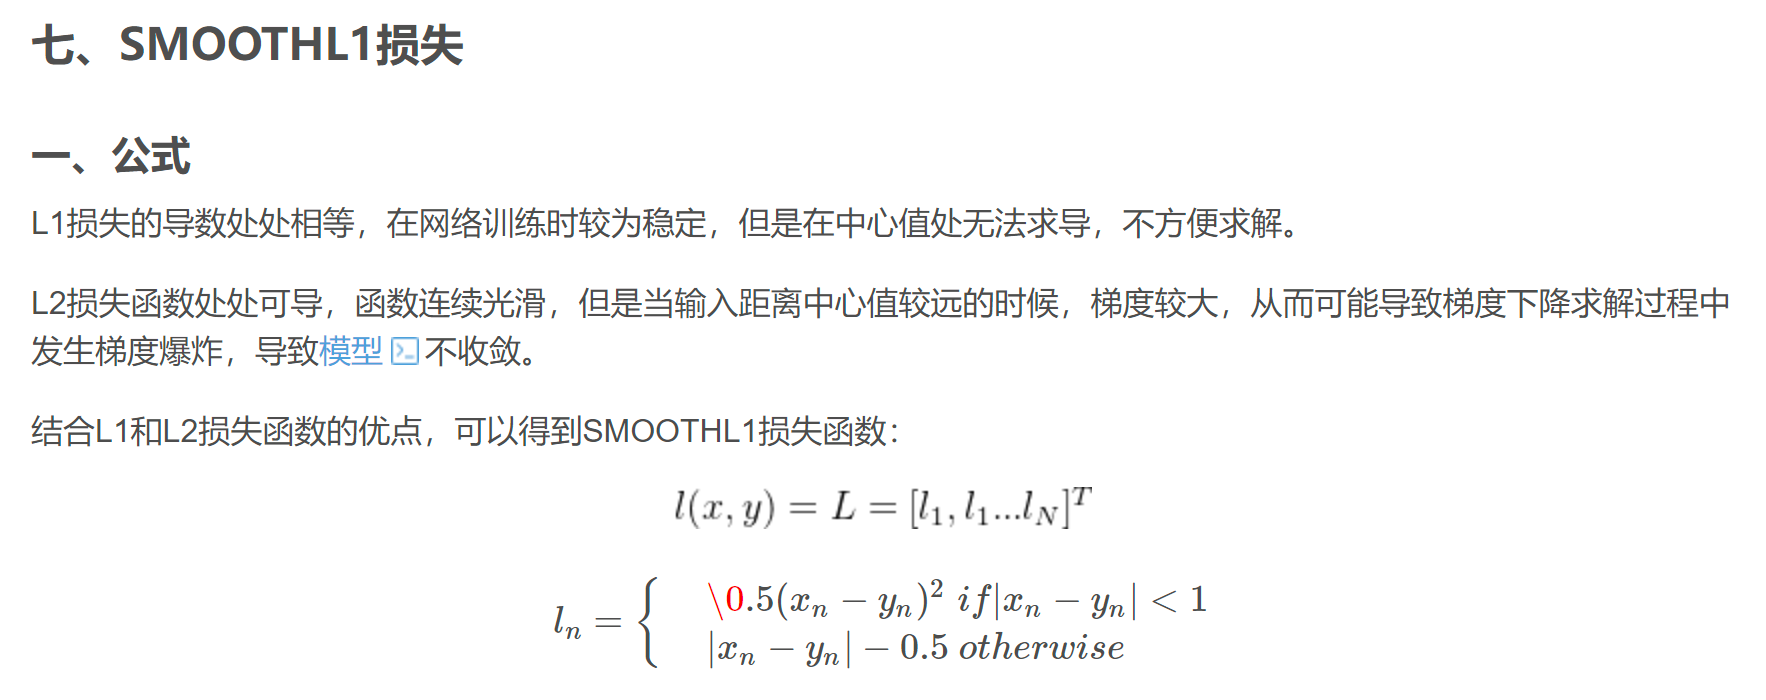

In [9]:

def smooth_l1_loss(x, y, reduction='mean'):
    rel = np.abs(x - y)
    dif = rel - 0.5
    dif[rel < 1] = 0.5 * np.square(rel)[rel < 1]
    if reduction == 'mean':
        return np.mean(dif)
    elif reduction == 'sum':
        return np.sum(dif)
    return dif
 
 
np.random.seed(10001)
x = np.random.rand(4, 3, 100)
y = np.random.rand(4, 3, 100)
np_loss = smooth_l1_loss(x, y, 'mean')
torch_loss_fn = torch.nn.SmoothL1Loss(reduction='mean')
torch_loss = torch_loss_fn(torch.from_numpy(x), torch.from_numpy(y))
print(np_loss, torch_loss.numpy())
# 输出：0.08140871478872054 0.08140871478872053

0.08140871478872054 0.08140871478872053
